Next you'll transfer the following files from the earlier part of this notebook into a directory on the pynq-z2:

bitfile: hls4ml_prj/myproject_vivado_accelerator/project_1.runs/impl_1/design_1_wrapper.bit -> hls4ml_nn.bit
hardware handoff: hls4ml_prj/myproject_vivado_accelerator/project_1.srcs/sources_1/bd/design_1/hw_handoff/design_1.hwh -> hls4ml_nn.hwh
driver: hls4ml_prj/axi_stream_driver.py -> axi_stream_driver.py
data: x_test.npy, y_test.npy
notebook: deployment.ipynb

through scp : ssh xilinx@172.17.64.155

In [2]:
! H=xilinx@172.17.64.155; D=/home/xilinx/jupyter_notebooks/getting_started/work; ssh $H "mkdir -p $D" && scp hls4ml_prj/myproject_vivado_accelerator/project_1.runs/impl_1/design_1_wrapper.bit $H:$D/hls4ml_nn.bit && scp hls4ml_prj/myproject_vivado_accelerator/project_1.srcs/sources_1/bd/design_1/hw_handoff/design_1.hwh $H:$D/hls4ml_nn.hwh && scp hls4ml_prj/axi_stream_driver.py x_test.npy y_test.npy deployment.ipynb $H:$D/

design_1_wrapper.bit                          100% 3951KB   2.4MB/s   00:01    
design_1.hwh                                  100%  299KB   3.1MB/s   00:00    
axi_stream_driver.py                          100% 3463   528.6KB/s   00:00    
x_test.npy                                    100% 1531KB   2.1MB/s   00:00    
y_test.npy                                    100%   20KB   1.9MB/s   00:00    
deployment.ipynb                              100%   61KB   1.7MB/s   00:00    


The following section is the code to execute in the pynq-z2 jupyter notebook to execute NN inference.

The following cells are intended to run on a pynq-z2, they will not run on the server used to train and synthesize models!

First, import our driver Overlay class. We'll also load the test data.

In [1]:
from axi_stream_driver import NeuralNetworkOverlay
import numpy as np

X_test = np.load('x_test.npy')
y_test = np.load('y_test.npy')

Create a NeuralNetworkOverlay object. This will download the Overlay (bitfile) onto the PL of the pynq-z2. We provide the X_test.shape and y_test.shape to allocate some buffers for the data transfer.

In [2]:
nn = NeuralNetworkOverlay('hls4ml_nn.bit', X_test.shape, y_test.shape)

Now run the prediction! When we set profile=True the function times the inference, and prints out a summary as well as returning the profiling information. We also save the output to a file so we can do some validation.

In [3]:
y_hw, latency, throughput = nn.predict(X_test, profile=True)
np.save('y_hw.npy', y_hw)

Classified 500 samples in 0.022522 seconds (22200.515051949205 inferences / s)


## Inference Figures
After running prediction, this section shows a small prediction gallery and a confusion matrix heatmap for a quick quality check.

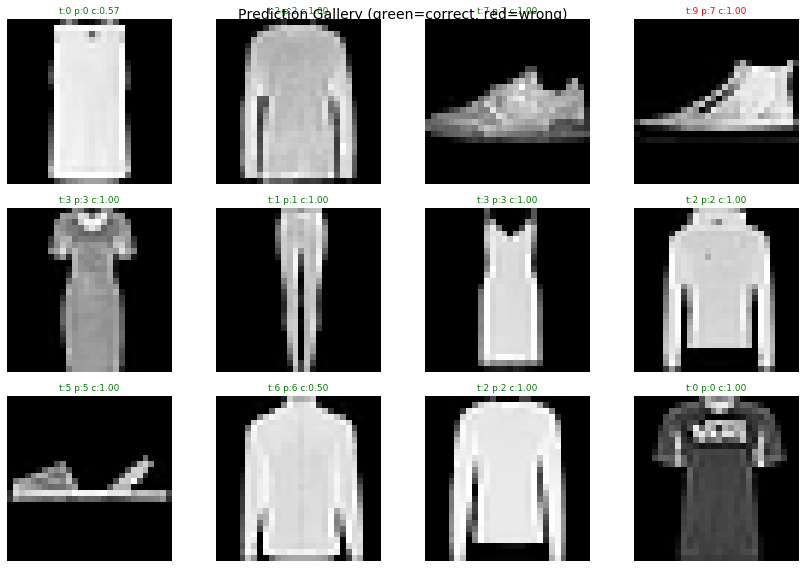

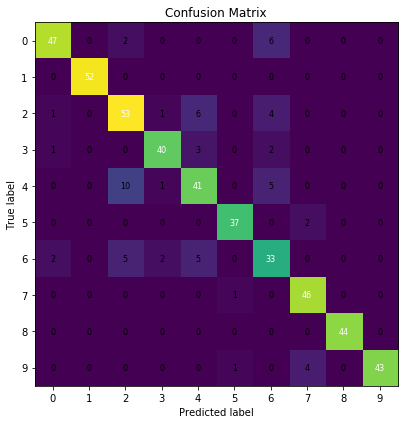

In [5]:
if 'y_hw' not in globals():
    print('Run Cell 8 first to generate y_hw, then rerun this cell.')
else:
    y_true = np.argmax(y_test, axis=1) if y_test.ndim > 1 else y_test.astype(int)
    y_pred = np.argmax(y_hw, axis=1) if y_hw.ndim > 1 else y_hw.astype(int)

    # Gallery: random predictions with confidence
    probs = y_hw if y_hw.ndim > 1 else None
    n_show = 12
    rng = np.random.default_rng(7)
    idxs = rng.choice(len(X_test), size=n_show, replace=False)

    fig, axes = plt.subplots(3, 4, figsize=(12, 8))
    for ax, idx in zip(axes.ravel(), idxs):
        img = X_test[idx]
        if img.ndim == 3 and img.shape[-1] == 1:
            img = img[..., 0]
        cmap = 'gray' if img.ndim == 2 else None
        ax.imshow(img, cmap=cmap)

        truth = int(y_true[idx])
        pred = int(y_pred[idx])
        conf = float(np.max(probs[idx])) if probs is not None else float('nan')
        color = 'green' if pred == truth else 'red'
        ax.set_title(f't:{truth} p:{pred} c:{conf:.2f}', color=color, fontsize=9)
        ax.axis('off')

    plt.suptitle('Prediction Gallery (green=correct, red=wrong)', fontsize=14)
    plt.tight_layout()
    plt.show()

    # Confusion matrix (pure numpy)
    n_classes = int(max(np.max(y_true), np.max(y_pred)) + 1)
    cm = np.zeros((n_classes, n_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[int(t), int(p)] += 1

    plt.figure(figsize=(7, 6))
    plt.imshow(cm, interpolation='nearest')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.xticks(np.arange(n_classes))
    plt.yticks(np.arange(n_classes))

    max_val = cm.max() if cm.size else 1
    for i in range(n_classes):
        for j in range(n_classes):
            val = cm[i, j]
            color = 'white' if val > max_val / 2 else 'black'
            plt.text(j, i, str(val), ha='center', va='center', color=color, fontsize=8)

    plt.tight_layout()
    plt.show()